Anomaly detection is a problem that is often implemented in business applications. One such example is quality analysis of manufactured products on a production line, where most products are produced correctly (meet standards), and a small number of samples are defective. Another example of anomaly detection is systems analyzing network traffic, where the goal is to detect outlier events, such as DDoS attacks.

The problem of anomaly detection can therefore be formalized as finding outlier samples/events, which typically appear rarely in the dataset. It can be said that the dataset contains many "typical" samples coming from a certain data distribution, and the goal is to find the few samples that come from outside this distribution.


## Task
Based on the provided dataset, propose a self-supervised or unsupervised algorithm for anomaly detection. Anomalies are labeled with `1`. Samples containing normal observations are labeled with `0`. **Use a neural network in your solution.** Finally, your solution should assign values to two global variables:
- `BATCH_SIZE` - the batch size that the dataloaders will operate on. During evaluation, we will read this value and use it for the dataloader with test data.
- `model` - a prepared model that will consist of a `forward()` function traditionally used for propagating data through the network, as well as a `predict()` function that will make the final assignment of a given sample to one of the classes: `0` or `1`. The `model` variable must be a trained instance of the `Model` class. `model` will be used to evaluate the solution on the test set.

**NOTE: The model can only be trained on the training set, which contains only normal observations.**

**NOTE: The variable names and the signature of the `predict` function must remain unchanged - you can use the checker to verify these requirements.**

## Grading
After training your prepared model, the `predict()` method will be called to evaluate the solution. It should contain a mechanism for assigning the input data sample based on the model's output and any additional criteria you have prepared for evaluating the model's predictions.
The quality of the proposed solution will be determined by calculating the classification accuracy on the test set, which is available to the organizers. The test set is **balanced**, and the images in it have the same characteristics as those provided to the participants.

A model achieving classification accuracy below 60% will receive 0 points, above 90% will receive 1 point, and intermediate values will be linearly scaled within this range. The final participant's score will be evaluated based on the formula below:
$$
score = min(max(accuracy - 0.6, 0.0), 0.3) / 0.3
$$

where $\mathrm{accuracy} \in [0, 1]$ is the classification accuracy on the test set.

## Submission files
1. This notebook only

## Constraints
- Evaluation of your solution (including neural network training, with the `FINAL_EVALUATION_MODE` flag set to `True`) on 10,000 test examples should take no longer than 15 minutes on Google Colab **with** GPU.

## Evaluation
Remember that during checking, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

You can earn between 0 and 1 points for this task. The number of points you earn will be equal to the `score` value calculated on the test set.

# Starter code

In [1]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

FINAL_EVALUATION_MODE = False
# When checking your solution, we will change this value to True
# This flag M U S T be set to False in the solution you send us!

In [2]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(0)
random.seed(0)
torch.manual_seed(0)

## Loading data

In [9]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

TRAIN_DIR: Path = Path("./train_data/train")
VALID_DIR: Path = Path("./valid_data/valid")

TRAIN_CSV: Path = Path("./train.csv")
VALID_CSV: Path = Path("./valid.csv")

In [4]:
# Set your batch size -- we will require this variable during checking and will use it during tests
BATCH_SIZE: int = 32

In [10]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

class ImageDataset(Dataset):
    def __init__(self, dir: Path, csv: Path):
        self.dir: Path = dir
        self.csv = pd.read_csv(csv)

    def __len__(self):
        return len(self.csv)

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        if torch.is_tensor(idx):
            idx = idx.tolist()
        path, label = self.csv.iloc[idx]
        img = plt.imread(self.dir / path)

        to_tensor = transforms.ToTensor()
        return to_tensor(img).cuda(), label


def train_dataloader() -> DataLoader:
    """Create DataLoader with training data."""
    return DataLoader(ImageDataset(TRAIN_DIR, TRAIN_CSV), batch_size=BATCH_SIZE, shuffle=True)


def valid_dataloader() -> DataLoader:
    """Create DataLoader with validation data."""
    return DataLoader(ImageDataset(VALID_DIR, VALID_CSV), batch_size=BATCH_SIZE, shuffle=False)

# Example solution skeleton + naive solution

Below we present a simple solution, which is obviously not optimal. It is intended to show how the entire notebook should work.

In [46]:
import copy
from torchmetrics.image import StructuralSimilarityIndexMeasure

class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.threshold = 5e-3
        latent_channels = 128

        self.encoder = nn.Sequential(
            self._block(3,   32,  stride=2),   # → 64x64
            self._block(32,  64,  stride=2),   # → 32x32
            self._block(64,  128, stride=2),   # → 16x16
            self._block(128, latent_channels, stride=2),  # → 8x8
        )
        self.encoder_fc = nn.Linear(8 * 8 * 128, 32)
        self.decoder_fc = nn.Linear(32, 8 * 8 * 128)

        # Decoder: 8 → 16 → 32 → 64 → 128
        self.decoder = nn.Sequential(
            self._up_block(latent_channels, 128),  # → 16x16
            self._up_block(128, 64),               # → 32x32
            self._up_block(64,  32),               # → 64x64
            self._up_block(32,  16),               # → 128x128
            nn.Conv2d(16, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def _block(self, in_ch, out_ch, stride):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),  # upsample+conv > ConvTranspose2d for blur
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    
    def forward(self, x):
        z = self.encoder(x)
        z = z.flatten(start_dim=1)
        z = self.encoder_fc(z)

        z = self.decoder_fc(z)
        z = z.reshape(-1, 128, 8, 8)
        return self.decoder(z)

    def predict(self, batch: torch.Tensor) -> torch.Tensor:
        recon = self(batch)
        diffs = ((recon - batch)**2).mean(dim=(1,2,3))
        preds = torch.tensor((diffs > self.threshold), dtype=torch.int32)
        return preds


def train_model() -> Model:
    """Create and train the model"""
    LR = 1e-3
    EPOCHS = 10

    loader = train_dataloader()
    model = Model().cuda()

    patience = 3
    i = 0
    best_loss = torch.inf
    best_state = None

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).cuda()
    def loss_fn(recon, original, alpha=0.6):
        l1 = F.l1_loss(recon, original)
        ssim_loss = 1 - ssim(recon, original)
        return alpha * l1 + (1-alpha) * ssim_loss

    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        
        for x in loader:
            if isinstance(x, (list, tuple)):
                x = x[0]
            
            x = x.float().cuda()

            recon = model(x)
            loss = loss_fn(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        total_loss /= len(loader)
        if total_loss > best_loss:
            i+=1
            if i >= patience:
                break
        else:
            best_loss = total_loss
            best_state = copy.deepcopy(model.state_dict())
        print(total_loss)

    model.load_state_dict(best_state)
    return model

In [47]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
# model = Model().cuda()
model = train_model()

0.22718402668493523
0.18743262055529852
0.18544401344099
0.18450737965705732
0.18409494198348425
0.1831826577856116
0.18294824823124767
0.1824659098909326
0.18228885334104164
0.18193394510441174


In [48]:
model.eval()
all_scores, all_labels = [], []
with torch.no_grad():
    for x, y in valid_dataloader():
        recon = model(x.float().cuda())
        scores = ((recon - x)**2).mean(dim=(1,2,3))
        all_scores.extend(scores.cpu().tolist())
        all_labels.extend(y.tolist())

scores = np.array(all_scores)
labels = np.array(all_labels)

best_thresh, best_acc = 0, 0
for t in np.percentile(scores, np.linspace(1, 99, 200)):
    preds = (scores > t).astype(int)
    acc = (preds == labels).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

model.threshold = best_thresh

In [49]:
frog_imgs = []
normal_imgs = []
for imgs, labels in valid_dataloader():
    for i in range(len(imgs)):
        if labels[i]==0 and len(normal_imgs) < 5:
            normal_imgs.append(imgs[i])
        elif labels[i]==1 and len(frog_imgs) < 5:
            frog_imgs.append(imgs[i])

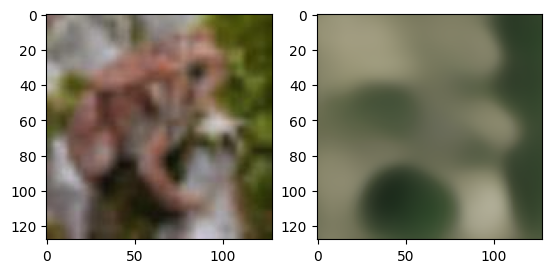

In [50]:
import matplotlib.pyplot as plt
batch = frog_imgs[2]
pred = model(batch.unsqueeze(0)).squeeze(0)
batch = batch.permute(1, 2, 0).detach().cpu().numpy()
pred = pred.permute(1, 2, 0).detach().cpu().numpy()
fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].imshow(batch)
ax[1].imshow(pred)

<Axes: ylabel='Count'>

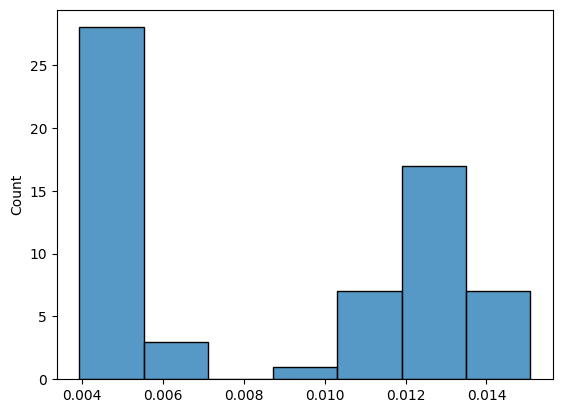

In [51]:
model.eval()
loss_fn = nn.MSELoss()

diffs = []
with torch.no_grad():
    for x in valid_dataloader():
        if isinstance(x, (list, tuple)):
            x = x[0]
        
        x = x.float().cuda()

        recon = model(x)
        loss = loss_fn(recon, x)

        diffs.append(loss.item())

import seaborn as sns
sns.histplot(diffs)

<Axes: ylabel='Proportion'>

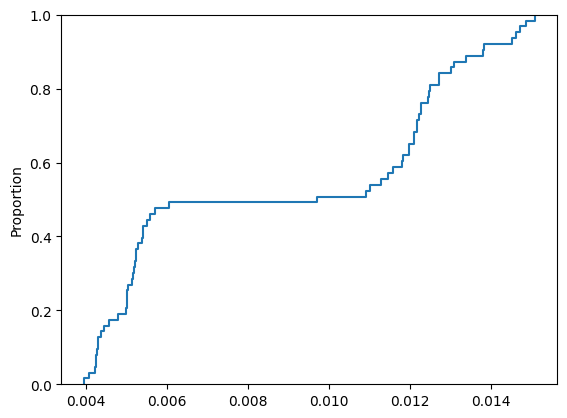

In [52]:
sns.ecdfplot(diffs)

# Grading criteria code

In [53]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################

def grade_solution(model):
    dataloader = valid_dataloader() # During checking, this will be replaced with test_dataloader

    predictions = np.concatenate([
        model.predict(images).cpu().to(dtype=torch.int32).numpy() for images, _ in dataloader
    ], axis=0)

    labels = np.concatenate([label for _, label in dataloader], axis=0, dtype=np.int32)

    accuracy = sum(labels == predictions) / len(labels)
    
    score = min(max(accuracy - 0.6, 0.0), 0.3) / 0.3

    print(f"Accuracy: {accuracy}")
    print(f'Your score is {score} points')
    return score

## Evaluation called on the provided dataset
(eventually will be run on the test dataset)

In [54]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
if not FINAL_EVALUATION_MODE:
    grade_solution(model)

Accuracy: 0.8215
Your score is 0.7383333333333335 points
